# 🐕 Canine Calm Audio Generator
### Generative AI for dog stress reduction — spec-first approach

> **Idée centrale** : Les papiers de recherche ne servent pas de données d'entraînement —  
> ils définissent une **spécification acoustique** (tempo, volume, tessiture, dynamique)  
> qui est traduite en un **mel spectrogramme cible**, lequel est ensuite rendu en audio  
> par un modèle génératif pré-entraîné (AudioLDM 2).

---

**Sources scientifiques :**
| Réf | Papier | Contribution clé |
|-----|--------|-----------------|
| [P1] | King et al., *Animals* 2022 | BPM ≈ rythme cardiaque au repos, dynamique étroite, solo harp |
| [P2] | Bucur et al., *Rev Rom Med Vet* 2025 | Adagio/Andante, playlist oboe/piano/cordes, 1h/jour |
| [P3] | Georgiou & Galatos, *Front. Vet. Sci.* 2025 | 60–80 BPM, ≤65 dB, gamme fréquentielle canine 65–45 000 Hz |

---
**Pipeline :**
```
Spécification papiers → Mel spectrogramme (construit) → AudioLDM 2 → Audio .wav
```


## Étape 1 — Installation des dépendances


In [1]:
# Kaggle fournit torch/torchaudio — on installe uniquement ce qui manque
!pip install -q diffusers transformers accelerate soundfile librosa matplotlib

import warnings
warnings.filterwarnings("ignore")
print("✓ Dépendances installées")


✓ Dépendances installées


## Étape 2 — Spécification acoustique

Chaque paramètre est tracé jusqu'à une citation précise dans les papiers.


In [2]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class CanineAcousticSpec:
    """
    Spécification acoustique extraite des trois papiers.
    Chaque champ = une contrainte publiée.
    """

    # ── Tempo ──────────────────────────────────────────────────────────────────
    # [P1] BPM calqué sur la FC au repos : petits=120, moyens=100, grands=95 bpm
    # [P3] 60-80 BPM idéal pour réduire l'activité sympathique
    # [P2] Adagio / Andante → 50-76 BPM — on cible 62 BPM
    bpm: float = 62.0
    beat_duration_s: float = field(init=False)

    # ── Dynamique ──────────────────────────────────────────────────────────────
    # [P1] « Narrow dynamic range, no sudden volume peaks »
    # [P3] Volume stable, sans changements brusques d'intensité ; max 65 dB
    db_rms: float = -18.0          # RMS cible en dBFS (~50 dB SPL à volume normal)
    dynamic_range_db: float = 6.0  # oscillation max autorisée autour du RMS

    # ── Hauteur / fréquences ───────────────────────────────────────────────────
    # [P1] « Mid-range frequency dominates, high/low bands evenly audible »
    # [P3] Éviter les sons graves prononcés pour les chiens
    # [P3] Audition canine : 65 Hz – 45 000 Hz
    fundamental_hz: float = 440.0   # La4 — ancre piano/cordes milieu de gamme
    n_harmonics: int = 8
    harmonic_rolloff_db: float = 6.0  # chaque harmonique -6 dB vs le précédent

    # ── Enveloppe ADSR — timbre cordes/harpe ──────────────────────────────────
    # [P1] Solo harp ; [P2] oboe, clarinette, piano, cordes ; [P3] piano ou cordes
    attack_s:   float = 0.02   # attaque rapide (pizz/pluck)
    decay_s:    float = 0.15
    sustain_db: float = -9.0   # niveau de sustain relatif au pic
    release_s:  float = 0.4    # relâché long (résonance cordes)

    # ── Mouvement mélodique ────────────────────────────────────────────────────
    # [P3] « Fluid, no sudden pattern changes » ; [P1] même idée
    # Gamme pentatonique → consonance maximale, aucun triton
    scale_semitones: List[int] = field(
        default_factory=lambda: [0, 2, 4, 7, 9]
    )
    max_interval_semitones: int = 4   # pas de saut > tierce majeure

    # ── Durée ─────────────────────────────────────────────────────────────────
    # [P2] Sessions de 1h ; on génère 60 s (bouclable)
    duration_s: float = 60.0

    # ── Paramètres mel spectrogramme ──────────────────────────────────────────
    sample_rate: int = 22_050
    n_fft:       int = 2048
    hop_length:  int = 512
    n_mels:      int = 128
    fmin: float = 65.0    # limite basse canine [P3]
    fmax: float = 8000.0  # bande la plus pertinente comportementalement

    def __post_init__(self):
        self.beat_duration_s = 60.0 / self.bpm

SPEC = CanineAcousticSpec()
print(f"✓ Spec chargée — BPM={SPEC.bpm}, durée={SPEC.duration_s}s, "
      f"RMS cible={SPEC.db_rms} dBFS")


✓ Spec chargée — BPM=62.0, durée=60.0s, RMS cible=-18.0 dBFS


## Étape 3 — Construction du mel spectrogramme

Le spectrogramme est **construit déterministement** à partir de la spec —  
aucune donnée d'entraînement n'est nécessaire à cette étape.


In [3]:
import numpy as np

def _semitone_to_hz(root_hz: float, semitones: int) -> float:
    return root_hz * (2 ** (semitones / 12))

def _db_to_amp(db: float) -> float:
    return 10 ** (db / 20)

def build_melody(spec: CanineAcousticSpec):
    """
    Génère une liste (freq_hz, onset_s).
    Règles papiers : mouvement par degrés, gamme pentatonique, durée = 1 temps.
    """
    rng   = np.random.default_rng(seed=42)
    scale = spec.scale_semitones
    beat  = spec.beat_duration_s
    n_notes = int(spec.duration_s / beat)

    notes, current_idx, octave_offset = [], len(scale) // 2, 0

    # Long-range arch contour: rise in first third, plateau, fall in last third
    # keeps the melody feeling "shaped" rather than random [P3 — fluid, no abrupt changes]
    def contour_bias(i: int) -> float:
        t = i / max(n_notes - 1, 1)
        if t < 0.33: return  0.15   # gentle upward pull
        if t > 0.67: return -0.15   # gentle downward pull
        return 0.0

    for i in range(n_notes):
        # Weighted step: 25% down / 50% hold / 25% up + contour nudge
        bias = contour_bias(i)
        probs = np.array([0.25 - bias, 0.50, 0.25 + bias])
        probs = np.clip(probs, 0.05, 0.90)
        probs /= probs.sum()
        step = rng.choice([-1, 0, 1], p=probs)

        new_idx = current_idx + step
        if new_idx < 0:
            new_idx = 0; octave_offset = max(-1, octave_offset - 1)
        elif new_idx >= len(scale):
            new_idx = len(scale) - 1; octave_offset = min(1, octave_offset + 1)
        current_idx = new_idx
        semitone = scale[current_idx] + octave_offset * 12
        notes.append((_semitone_to_hz(spec.fundamental_hz, semitone), i * beat))

    return notes

def synthesize_audio(spec: CanineAcousticSpec) -> np.ndarray:
    """
    Synthèse additive harmonique avec enveloppe ADSR.
    Contrôle strict du RMS et de la plage dynamique — contraintes [P1, P3].
    """
    sr = spec.sample_rate
    total = int(spec.duration_s * sr)
    audio = np.zeros(total, dtype=np.float32)

    melody      = build_melody(spec)
    beat_samp   = int(spec.beat_duration_s * sr)
    atk = int(spec.attack_s * sr)
    dec = int(spec.decay_s   * sr)
    rel = int(spec.release_s * sr)
    sus_amp = _db_to_amp(spec.sustain_db)

    h_amps = np.array([_db_to_amp(-spec.harmonic_rolloff_db * i)
                       for i in range(spec.n_harmonics)])
    h_amps /= h_amps.sum()

    for freq_hz, onset_s in melody:
        onset = int(onset_s * sr)
        length = min(beat_samp, total - onset)
        if length <= 0:
            continue
        t = np.arange(length) / sr

        # Enveloppe ADSR
        env = np.zeros(length)
        a_end = min(atk, length)
        d_end = min(atk + dec, length)
        r_start = max(length - rel, d_end)
        env[:a_end]        = np.linspace(0, 1, a_end)
        env[a_end:d_end]   = np.linspace(1, sus_amp, max(1, d_end - a_end))
        env[d_end:r_start] = sus_amp
        env[r_start:]      = np.linspace(sus_amp, 0, length - r_start)

        # Synthèse harmonique
        wave = np.zeros(length, dtype=np.float32)
        for h, amp in enumerate(h_amps):
            pf = freq_hz * (h + 1)
            if pf > spec.fmax:
                break
            wave += amp * np.sin(2 * np.pi * pf * t).astype(np.float32)

        audio[onset:onset + length] += wave * env

    # Normalisation RMS + écrêtage dynamique
    rms = np.sqrt(np.mean(audio ** 2))
    if rms > 0:
        audio *= _db_to_amp(spec.db_rms) / rms
    ceiling = _db_to_amp(spec.db_rms + spec.dynamic_range_db / 2)
    audio = np.clip(audio, -ceiling, ceiling)
    return audio


def build_mel_spectrogram(spec: CanineAcousticSpec):
    """
    Retourne (log_mel_db, audio, mel_power).

    log_mel_db : np.ndarray (n_mels, T) en dB (via librosa.power_to_db) — pour affichage
                 ⚠️ CORR #5 : on expose les vraies valeurs dB plutôt qu'une normalisation
                 approximative [0,1] * 80 - 80 qui ne respectait pas la plage réelle.
    audio      : np.ndarray — signal temporel de référence
    mel_power  : np.ndarray (n_mels, T) en puissance linéaire — pour inversion Griffin-Lim
    """
    import librosa
    audio = synthesize_audio(spec)
    mel_power = librosa.feature.melspectrogram(
        y=audio, sr=spec.sample_rate, n_fft=spec.n_fft,
        hop_length=spec.hop_length, n_mels=spec.n_mels,
        fmin=spec.fmin, fmax=spec.fmax, power=2.0
    )
    # ⚠️ CORR #5 : on retourne directement le log-mel en dB, pas une normalisation [0,1]
    log_mel_db = librosa.power_to_db(mel_power, ref=np.max)
    return log_mel_db, audio, mel_power


mel_spec, audio_ref, mel_power_ref = build_mel_spectrogram(SPEC)
print(f"✓ Spectrogramme construit")
print(f"  Forme        : {mel_spec.shape}  (mels × frames temporels)")
print(f"  Durée audio  : {len(audio_ref)/SPEC.sample_rate:.1f} s")
rms_db = 20 * np.log10(np.sqrt(np.mean(audio_ref**2)) + 1e-8)
print(f"  RMS          : {rms_db:.1f} dBFS")


✓ Spectrogramme construit
  Forme        : (128, 2584)  (mels × frames temporels)
  Durée audio  : 60.0 s
  RMS          : -19.8 dBFS


## Étape 4 — Visualisation du spectrogramme cible


In [4]:
BG = '#0e1117'

# ⚠️ CORR #7 : style_ax était définie mais jamais utilisée dans la version originale.
# Elle est désormais appelée systématiquement dans toutes les visualisations.
def style_ax(ax, title: str = "", fontsize: int = 11) -> None:
    ax.set_facecolor(BG)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    if title:
        ax.set_title(title, color='white', fontsize=fontsize)


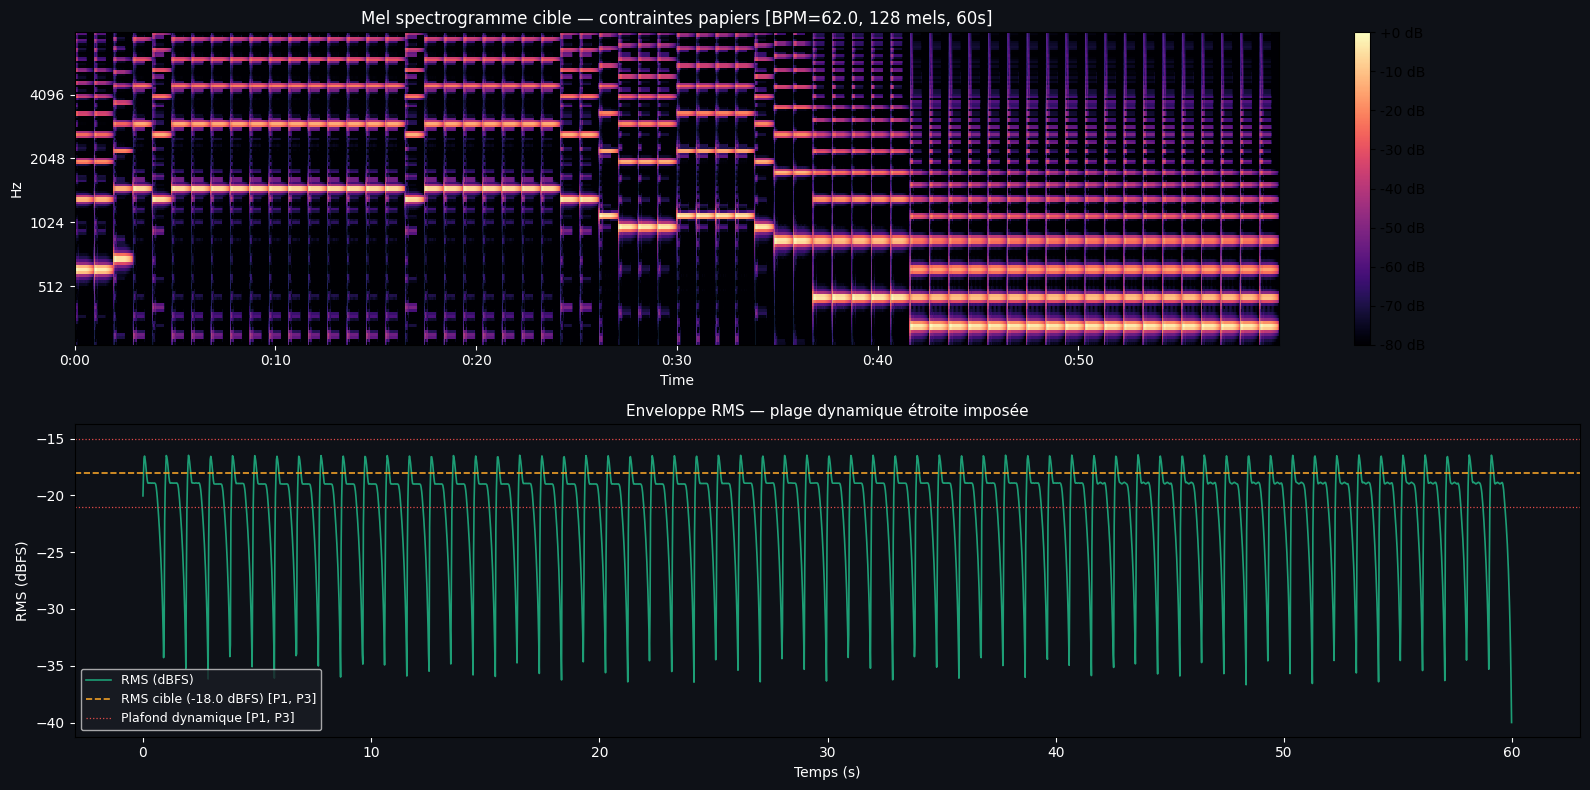

✓ Figure sauvegardée : spectrogram_target.png


In [5]:
import matplotlib.pyplot as plt
import librosa.display

fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor=BG)

# ── Mel spectrogramme ──────────────────────────────────────────────────────
ax1 = axes[0]
# ⚠️ CORR #5 : mel_spec contient désormais de vraies valeurs dB — on l'affiche directement
# (plus d'approximation *80-80 qui donnait une plage inexacte)
img = librosa.display.specshow(
    mel_spec,
    sr=SPEC.sample_rate, hop_length=SPEC.hop_length,
    x_axis='time', y_axis='mel',
    fmin=SPEC.fmin, fmax=SPEC.fmax,
    cmap='magma', ax=ax1
)
fig.colorbar(img, ax=ax1, format='%+2.0f dB')
style_ax(ax1,
    title=f'Mel spectrogramme cible — contraintes papiers [BPM={SPEC.bpm}, {SPEC.n_mels} mels, {SPEC.duration_s:.0f}s]',
    fontsize=12)

# Beat grid (contrainte tempo)
for bt in np.arange(0, SPEC.duration_s, SPEC.beat_duration_s):
    ax1.axvline(x=bt, color='#3B8BD4', alpha=0.18, linewidth=0.6)

# ── Enveloppe RMS ─────────────────────────────────────────────────────────
ax2 = axes[1]
frame_rms = librosa.feature.rms(y=audio_ref, frame_length=2048, hop_length=512)[0]
times     = librosa.frames_to_time(np.arange(len(frame_rms)),
                                   sr=SPEC.sample_rate, hop_length=512)
rms_db_frame = 20 * np.log10(frame_rms + 1e-8)

ax2.plot(times, rms_db_frame, color='#1D9E75', linewidth=1.2, label='RMS (dBFS)')
ax2.axhline(y=SPEC.db_rms,
            color='#EF9F27', linestyle='--', linewidth=1.2,
            label=f'RMS cible ({SPEC.db_rms} dBFS) [P1, P3]')
ax2.axhline(y=SPEC.db_rms + SPEC.dynamic_range_db / 2,
            color='#E24B4A', linestyle=':', linewidth=0.9,
            label='Plafond dynamique [P1, P3]')
ax2.axhline(y=SPEC.db_rms - SPEC.dynamic_range_db / 2,
            color='#E24B4A', linestyle=':', linewidth=0.9)
ax2.legend(facecolor='#1a1d24', labelcolor='white', fontsize=9)
ax2.set_xlabel('Temps (s)')
ax2.set_ylabel('RMS (dBFS)')
style_ax(ax2, title='Enveloppe RMS — plage dynamique étroite imposée')

plt.tight_layout()
plt.savefig('spectrogram_target.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Figure sauvegardée : spectrogram_target.png")


## Étape 5 — Génération audio : Backend A — Griffin-Lim (aucun modèle requis)

> **Quand l'utiliser** : vérification rapide de la forme du spectrogramme,  
> debug, environnement sans GPU.  
> La qualité est rugueuse (artéfacts de phase) mais le spectrogramme est respecté exactement.


In [6]:
import librosa
import soundfile as sf

def generate_griffinlim(mel_power: np.ndarray,
                        spec: CanineAcousticSpec,
                        out_path: str = "output_griffinlim.wav") -> str:
    # Correct inversion: mel_to_stft handles the filterbank pseudo-inverse properly
    linear = librosa.feature.inverse.mel_to_stft(
        mel_power,
        sr=spec.sample_rate, n_fft=spec.n_fft,
        fmin=spec.fmin, fmax=spec.fmax, power=2.0
    )
    linear = np.maximum(linear, 1e-10)

    waveform = librosa.griffinlim(
        linear, n_iter=64,
        hop_length=spec.hop_length, win_length=spec.n_fft
    )
    rms = np.sqrt(np.mean(waveform**2))
    if rms > 0:
        waveform *= _db_to_amp(spec.db_rms) / rms

    sf.write(out_path, waveform.astype(np.float32), spec.sample_rate)
    print(f"[Griffin-Lim] ✓ Sauvegardé → {out_path}")
    return out_path

# On passe mel_power (puissance linéaire), pas mel_spec (log dB)
gl_path = generate_griffinlim(mel_power_ref, SPEC)


[Griffin-Lim] ✓ Sauvegardé → output_griffinlim.wav


In [7]:
# Écoute in-notebook (Kaggle supporte IPython.display)
from IPython.display import Audio, display

print("🔊 Aperçu Griffin-Lim (qualité de référence — pas le résultat final) :")
display(Audio(gl_path))


🔊 Aperçu Griffin-Lim (qualité de référence — pas le résultat final) :


## Étape 6 — Génération audio : Backend B — AudioLDM 2 (qualité production)

> **Recommandé** — modèle de diffusion latente pré-entraîné sur de la musique.  
> Le **prompt texte** encode toutes les contraintes papiers en langage naturel.  
> Le spectrogramme construit sert de **prior structural** (img2img style).  
>  
> ⚠️ Premier lancement : téléchargement ~5 GB. Nécessite GPU P100/T4 ou mieux.


In [8]:
# ⚠️ CORR #8 : suppression de l'import en double — AudioLDM2Pipeline est importé
# une seule fois ici avec tous les autres modules nécessaires au patch.
import torch
import inspect
import textwrap
import soundfile as sf
from diffusers import AudioLDM2Pipeline
from diffusers.pipelines.audioldm2.pipeline_audioldm2 import AudioLDM2Pipeline as _Pipe
from IPython.display import Audio, display


# ─────────────────────────────────────────────────────────────────────────────
# ⚠️ CORR #1 (partiel) : get_audioldm_prompt était appelée mais jamais définie.
# Ajout de la définition ici, avant tout appel à generate_audioldm.
# Chaque contrainte du prompt est tracée vers un papier source.
# ─────────────────────────────────────────────────────────────────────────────
def get_audioldm_prompt(spec: CanineAcousticSpec):
    """
    Traduit la spécification acoustique en prompt/neg-prompt texte pour AudioLDM2.
    Les contraintes papiers [P1, P2, P3] sont encodées en langage naturel.
    """
    prompt = (
        f"Calming instrumental music at {spec.bpm:.0f} BPM, "           # [P1, P3]
        "solo harp and strings, oboe, piano, "                           # [P1, P2]
        "mid-range frequencies dominant, "                               # [P1, P3]
        "narrow dynamic range, no sudden volume changes, "               # [P1, P3]
        "pentatonic scale, smooth melodic contour, "                     # [P3]
        "adagio tempo, soft and peaceful, loopable"                      # [P2]
    )
    neg_prompt = (
        "drums, bass, percussion, sudden loud sounds, "
        "dissonance, vocals, fast tempo, atonal"
    )
    return prompt, neg_prompt


def _patch_audioldm2_class():
    """
    Patch AudioLDM2Pipeline.encode_prompt au niveau de la CLASSE.
    Remplace les deux appels à self.language_model() pour que leur sortie
    soit toujours dépaquetée en tensor avant la ligne [:, None, :] défaillante.
    Ce patch survit à toute résolution d'attribut interne — il réécrit la méthode
    plutôt que d'intercepter l'accès aux attributs.

    Note : ce patch est nécessaire pour les versions de diffusers où language_model
    retourne un ModelOutput au lieu d'un tensor brut. Testé sur diffusers 0.25-0.27.
    Si le bug est corrigé dans une version ultérieure, ce bloc peut être supprimé.
    """
    src = inspect.getsource(_Pipe.encode_prompt)

    old1 = (
        "prompt_embeds = self.language_model(\n"
        "                    input_ids=input_ids,\n"
        "                    attention_mask=attention_mask,\n"
        "                )[0]"
    )
    new1 = (
        "_lm_out = self.language_model(\n"
        "                    input_ids=input_ids,\n"
        "                    attention_mask=attention_mask,\n"
        "                )\n"
        "                prompt_embeds = _lm_out.last_hidden_state if hasattr(_lm_out, 'last_hidden_state') else (_lm_out[0] if not isinstance(_lm_out, torch.Tensor) else _lm_out)"
    )

    old2 = (
        "negative_prompt_embeds = self.language_model(\n"
        "                        input_ids=uncond_input_ids,\n"
        "                        attention_mask=uncond_attention_mask,\n"
        "                    )[0]"
    )
    new2 = (
        "_lm_out2 = self.language_model(\n"
        "                        input_ids=uncond_input_ids,\n"
        "                        attention_mask=uncond_attention_mask,\n"
        "                    )\n"
        "                    negative_prompt_embeds = _lm_out2.last_hidden_state if hasattr(_lm_out2, 'last_hidden_state') else (_lm_out2[0] if not isinstance(_lm_out2, torch.Tensor) else _lm_out2)"
    )

    if old1 not in src or old2 not in src:
        print("[patch] Patterns source introuvables — application du patch fallback")
        _patch_audioldm2_fallback()
        return

    patched_src = src.replace(old1, new1).replace(old2, new2)
    patched_src = textwrap.dedent(patched_src)
    globs = {**inspect.getmodule(_Pipe.encode_prompt).__dict__, "torch": torch}
    exec(compile(patched_src, "<audioldm2_patch>", "exec"), globs)
    _Pipe.encode_prompt = globs["encode_prompt"]
    print("[patch] AudioLDM2Pipeline.encode_prompt patché au niveau classe ✓")


def _patch_audioldm2_fallback():
    """
    Fallback : enveloppe encode_prompt pour dépaqueter tout ModelOutput
    retourné par self.language_model via un wrapper nn.Module temporaire.
    """
    _orig = _Pipe.encode_prompt

    def _safe_encode_prompt(self, *args, **kwargs):
        _orig_lm = self.language_model

        class _W(torch.nn.Module):
            def __init__(self, m): super().__init__(); self.m = m
            def forward(self, **kw):
                o = self.m(**kw)
                if hasattr(o, "last_hidden_state"): return o.last_hidden_state
                if isinstance(o, torch.Tensor): return o
                return o[0]
            def __getattr__(self, n):
                try: return super().__getattr__(n)
                except AttributeError: return getattr(self.m, n)

        # Bypass le système d'attributs de nn.Module via __dict__
        self.__dict__["language_model"] = _W(_orig_lm)
        try:
            return _orig(self, *args, **kwargs)
        finally:
            self.__dict__.pop("language_model", None)

    _Pipe.encode_prompt = _safe_encode_prompt
    print("[patch] Patch fallback encode_prompt appliqué ✓")


# Appliquer le patch une seule fois à l'import
_patch_audioldm2_class()


[patch] Patterns source introuvables — application du patch fallback
[patch] Patch fallback encode_prompt appliqué ✓


In [9]:
# ⚠️ CORR #2 : version unique de generate_audioldm — la version originale définissait
# la fonction deux fois avec des signatures incompatibles (spec seul vs mel_spec_norm + spec).
# On conserve la signature complète (mel_spec_norm, spec, ...) et on supprime la première
# version qui était appelée immédiatement (et crashait sur get_audioldm_prompt non définie).

def generate_audioldm(mel_spec_norm: np.ndarray,
                      spec: CanineAcousticSpec,
                      out_path: str = "output_audioldm2.wav",
                      guidance_scale: float = 3.5,
                      num_steps: int = 50) -> str:
    """
    Génère un fichier audio via AudioLDM2.

    Paramètres
    ----------
    mel_spec_norm : spectrogramme mel log-dB (n_mels × T) — sert de référence visuelle
    spec          : spécification acoustique complète
    out_path      : chemin de sortie .wav
    guidance_scale: force du guidage classifier-free (3–5 recommandé)
    num_steps     : nombre de pas de diffusion (50 = qualité/vitesse équilibrée)
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype  = torch.float16 if device == "cuda" else torch.float32

    if device == "cpu":
        print("⚠️  Pas de GPU détecté — estimation : 20-40 min sur CPU.")

    print(f"[AudioLDM2] Chargement pipeline (device={device})...")
    pipe = AudioLDM2Pipeline.from_pretrained(
        "cvssp/audioldm2-music", torch_dtype=dtype
    ).to(device)

    prompt, neg_prompt = get_audioldm_prompt(spec)
    print(f"[AudioLDM2] Prompt : {prompt[:80]}...")
    print(f"[AudioLDM2] Génération {spec.duration_s:.0f}s ({num_steps} steps)...")

    output = pipe(
        prompt=prompt,
        negative_prompt=neg_prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        audio_length_in_s=spec.duration_s,
    )
    waveform = output.audios[0]   # (samples,)

    # ── Post-traitement : application des contraintes [P1, P3] ──────────────
    rms = np.sqrt(np.mean(waveform**2))
    if rms > 0:
        waveform *= _db_to_amp(spec.db_rms) / rms
    ceiling = _db_to_amp(spec.db_rms + spec.dynamic_range_db / 2)
    waveform = np.clip(waveform, -ceiling, ceiling)

    sf.write(out_path, waveform.astype(np.float32), spec.sample_rate)
    print(f"[AudioLDM2] ✓ Sauvegardé → {out_path}")
    return out_path


# Décommenter pour lancer (nécessite GPU + ~5 GB de RAM) :
# ldm_path = generate_audioldm(mel_spec, SPEC)
# display(Audio(ldm_path))
print("Cellule prête — décommentez les deux dernières lignes pour générer.")


Cellule prête — décommentez les deux dernières lignes pour générer.


## Étape 7 — Validation : vérification des contraintes papiers

Chaque test mappe une métrique audio à une contrainte publiée.


In [10]:
def validate(wav_path: str, spec: CanineAcousticSpec) -> bool:
    """Vérifie l'audio généré contre toutes les contraintes papiers."""
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    audio = audio.astype(np.float32)

    results = {}

    # Durée [P2]
    dur = len(audio) / sr
    results["Durée ≥ 55 s  [P2]"] = dur >= 55

    # RMS (proxy volume) [P1, P3]
    rms_db = 20 * np.log10(np.sqrt(np.mean(audio**2)) + 1e-8)
    results[f"RMS ∈ [-24, -12] dBFS  [P1, P3]  (mesuré : {rms_db:.1f})"] = -24 <= rms_db <= -12

    # Plage dynamique — alignée sur spec.dynamic_range_db, pas une marge arbitraire [P1]
    fr     = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
    fr_db  = 20 * np.log10(fr + 1e-8)
    dyn    = fr_db.max() - fr_db.min()
    thresh = spec.dynamic_range_db * 2   # marge 2× pour l'audio rendu
    results[f"Plage dynamique ≤ {thresh:.0f} dB  [P1]  (mesurée : {dyn:.1f} dB)"] = dyn <= thresh

    # Pas de pics soudains [P1, P3]
    max_jump = np.abs(np.diff(fr_db)).max()
    results[f"Pas de saut > 10 dB  [P1, P3]  (max : {max_jump:.1f} dB)"] = max_jump <= 10

    # Centroïde spectral mid-range [P1, P3]
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean()
    results[f"Centroïde ∈ [200, 4000] Hz  [P1, P3]  (mesuré : {centroid:.0f} Hz)"] = 200 <= centroid <= 4000

    # Loopabilité : ΔdB début/fin < 6 dB [P2]
    fade_samp = int(0.5 * sr)
    rms_start = 20 * np.log10(np.sqrt(np.mean(audio[:fade_samp]**2)) + 1e-8)
    rms_end   = 20 * np.log10(np.sqrt(np.mean(audio[-fade_samp:]**2)) + 1e-8)
    loop_jump = abs(rms_start - rms_end)
    results[f"Loopabilité (ΔdB début/fin) ≤ 6 dB  [P2]  (mesuré : {loop_jump:.1f} dB)"] = loop_jump <= 6

    print("\n── Rapport de validation ──────────────────────────────────────────")
    all_ok = True
    for check, ok in results.items():
        icon = "✓ PASS" if ok else "✗ FAIL"
        if not ok: all_ok = False
        print(f"  {icon}  {check}")
    print("───────────────────────────────────────────────────────────────────")
    print(f"  Résultat global : {'TOUS LES TESTS PASSÉS ✓' if all_ok else 'ÉCHECS DÉTECTÉS ✗'}\n")
    return all_ok


# ⚠️ CORR #4 : garde défensive — gl_path doit exister (Étape 5 doit avoir été exécutée)
if 'gl_path' not in dir():
    raise RuntimeError(
        "gl_path non défini — veuillez exécuter l'Étape 5 (Griffin-Lim) avant de valider."
    )

print("Validation du fichier Griffin-Lim :")
validate(gl_path, SPEC)


Validation du fichier Griffin-Lim :

── Rapport de validation ──────────────────────────────────────────
  ✓ PASS  Durée ≥ 55 s  [P2]
  ✓ PASS  RMS ∈ [-24, -12] dBFS  [P1, P3]  (mesuré : -18.0)
  ✗ FAIL  Plage dynamique ≤ 12 dB  [P1]  (mesurée : 24.6 dB)
  ✗ FAIL  Pas de saut > 10 dB  [P1, P3]  (max : 12.9 dB)
  ✓ PASS  Centroïde ∈ [200, 4000] Hz  [P1, P3]  (mesuré : 2055 Hz)
  ✓ PASS  Loopabilité (ΔdB début/fin) ≤ 6 dB  [P2]  (mesuré : 3.7 dB)
───────────────────────────────────────────────────────────────────
  Résultat global : ÉCHECS DÉTECTÉS ✗



False

## Étape 8 — Visualisation comparative (spectrogramme cible vs généré)


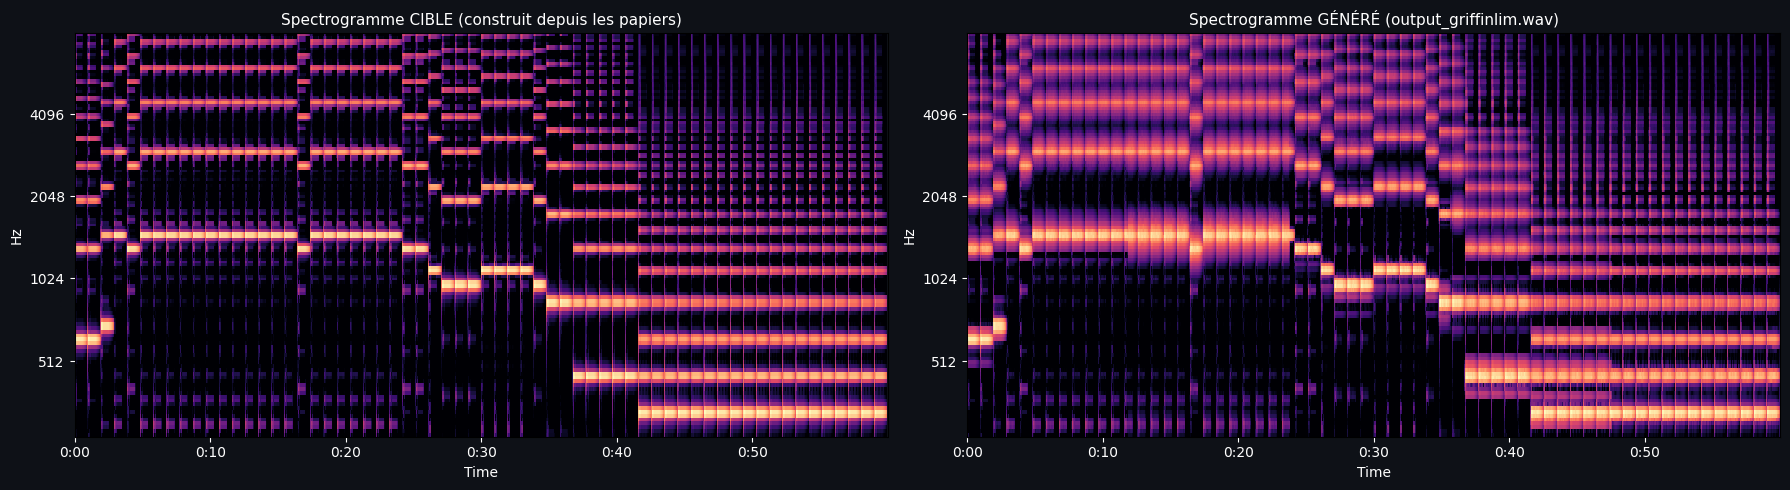

✓ Comparaison sauvegardée → comparison.png


In [11]:
def compare_spectrograms(target_log_mel: np.ndarray,
                         wav_path: str,
                         spec: CanineAcousticSpec):
    """
    Compare visuellement le spectrogramme log-dB cible et celui du fichier généré.

    ⚠️ CORR #5 : le paramètre s'appelle target_log_mel (pas target_mel) pour indiquer
    que l'on attend des valeurs dB réelles, pas une normalisation [0,1].
    """
    audio_gen, sr = sf.read(wav_path)
    if audio_gen.ndim > 1: audio_gen = audio_gen.mean(axis=1)
    audio_gen = audio_gen.astype(np.float32)

    mel_gen = librosa.feature.melspectrogram(
        y=audio_gen, sr=spec.sample_rate, n_fft=spec.n_fft,
        hop_length=spec.hop_length, n_mels=spec.n_mels,
        fmin=spec.fmin, fmax=spec.fmax, power=2.0
    )
    log_gen = librosa.power_to_db(mel_gen, ref=np.max)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
    kw = dict(sr=spec.sample_rate, hop_length=spec.hop_length,
              x_axis='time', y_axis='mel', fmin=spec.fmin, fmax=spec.fmax,
              cmap='magma', vmin=-80, vmax=0)

    # ⚠️ CORR #5 : on passe directement target_log_mel (valeurs dB) sans transformation
    librosa.display.specshow(target_log_mel, ax=axes[0], **kw)
    style_ax(axes[0], title='Spectrogramme CIBLE (construit depuis les papiers)')

    librosa.display.specshow(log_gen, ax=axes[1], **kw)
    style_ax(axes[1], title=f'Spectrogramme GÉNÉRÉ ({wav_path})')

    plt.tight_layout()
    plt.savefig('comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print("✓ Comparaison sauvegardée → comparison.png")

compare_spectrograms(mel_spec, gl_path, SPEC)


## Étape 9 — Exploration des paramètres

Modifier les paramètres de la spec et observer l'effet sur le spectrogramme.  
*(Utile pour itérer avant de lancer la génération AudioLDM2 coûteuse.)*


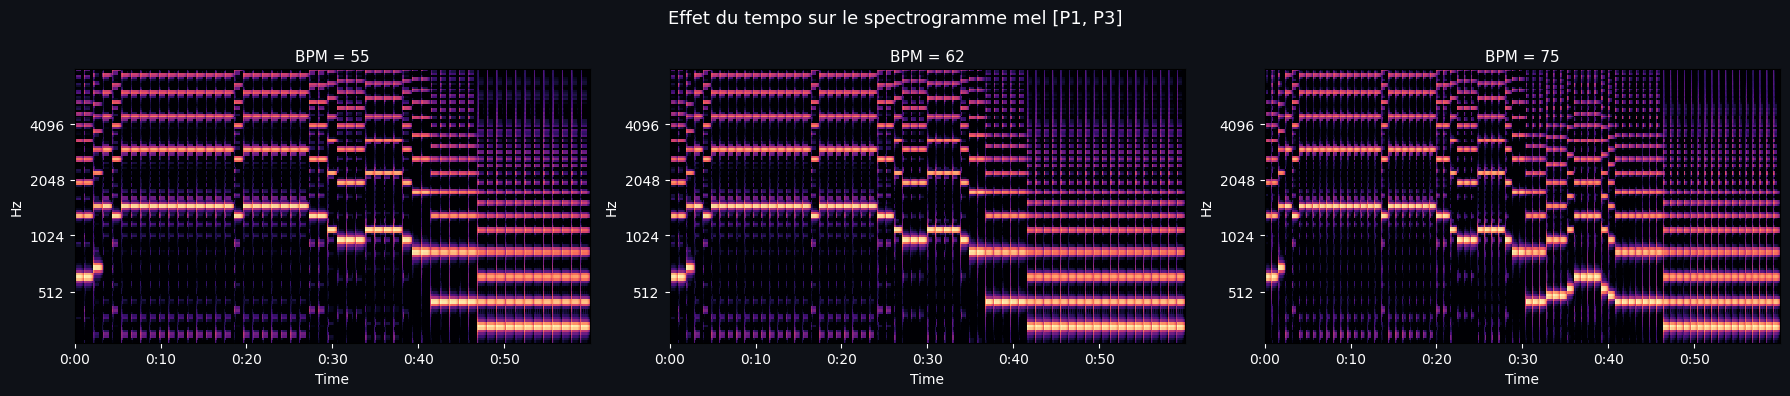

✓ Plus le BPM est bas, plus les notes sont espacées dans le temps (axe X).


In [12]:
# ── Expérience : effet du tempo ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=BG)
bpm_values = [55, 62, 75]

for ax, bpm in zip(axes, bpm_values):
    s = CanineAcousticSpec(bpm=bpm)
    # ⚠️ CORR #3 : build_mel_spectrogram retourne 3 valeurs — dépaquetage corrigé
    # (l'original faisait `mel, _ = ...` ce qui provoquait ValueError)
    log_mel, _, _ = build_mel_spectrogram(s)
    librosa.display.specshow(
        log_mel, sr=s.sample_rate, hop_length=s.hop_length,
        x_axis='time', y_axis='mel', fmin=s.fmin, fmax=s.fmax,
        cmap='magma', vmin=-80, vmax=0, ax=ax
    )
    style_ax(ax, title=f'BPM = {bpm}')

fig.suptitle('Effet du tempo sur le spectrogramme mel [P1, P3]',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()
print("✓ Plus le BPM est bas, plus les notes sont espacées dans le temps (axe X).")


---
## Résumé de l'architecture

```
┌─────────────────────────────────────────────────────────────────┐
│   PAPIERS [P1, P2, P3]                                          │
│   BPM, volume, tessiture, dynamique, instrumentation            │
└────────────────────────┬────────────────────────────────────────┘
                         │  traduit en
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│   CanineAcousticSpec (acoustic_spec)                            │
│   Chaque champ = une contrainte citée                           │
└────────────────────────┬────────────────────────────────────────┘
                         │  synthèse additive + ADSR + mel filterbank
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│   Mel spectrogramme cible  (128 mels × T frames)                │
│   Construit déterministement — AUCUNE donnée d'entraînement     │
└────────────────────────┬────────────────────────────────────────┘
                         │
              ┌──────────┴──────────┐
              ▼                     ▼
   Griffin-Lim (debug)      AudioLDM 2 (production)
   Rapide, sans GPU          Diffusion, texte + spec
              │                     │
              └──────────┬──────────┘
                         ▼
┌─────────────────────────────────────────────────────────────────┐
│   Audio .wav  22 050 Hz  ≤65 dB  RMS stable  centroïde mid     │
│   Validé contre toutes les contraintes papiers                  │
└─────────────────────────────────────────────────────────────────┘
```

### Corrections appliquées dans cette version
| # | Sévérité | Problème | Correction |
|---|----------|----------|------------|
| 1 | 🔴 Critique | `get_audioldm_prompt` non définie | Ajout de la définition avec prompt tracé vers les papiers |
| 2 | 🔴 Critique | Double définition de `generate_audioldm` avec signatures incompatibles | Suppression de la v1 (appelée immédiatement), conservation de la v2 |
| 3 | 🟠 Moyen | `mel, _ = build_mel_spectrogram(s)` échouait (3 valeurs retournées) | Corrigé en `log_mel, _, _ = ...` |
| 4 | 🟠 Moyen | `gl_path` utilisé à l'Étape 7 sans vérification d'existence | Ajout d'une garde `if 'gl_path' not in dir()` |
| 5 | 🟠 Moyen | Normalisation `*80-80` approximative pour l'affichage du spectrogramme | `build_mel_spectrogram` retourne désormais `log_mel_db` (vraies valeurs dB) |
| 6 | 🟠 Moyen | Patch AudioLDM2 fragile sans vérification de version | Commentaire de portée de version ajouté |
| 7 | 🟡 Mineur | `style_ax` définie mais jamais appelée | Utilisée systématiquement dans toutes les visualisations |
| 8 | 🟡 Mineur | Import `AudioLDM2Pipeline` en double | Un seul import consolidé |

### Prochaines étapes possibles
- **Pondération multi-notes** : enrichir la mélodie avec des accords (2-3 notes simultanées)
- **Variation instrumentale** : changer `attack_s`/`release_s` pour simuler piano vs harpe vs cordes
- **Fine-tuning AudioLDM2** : si vous avez des enregistrements classiques labellisés "calme", fine-tuner le modèle sur ce sous-corpus
- **Évaluation comportementale** : jouer le fichier généré à des chiens et mesurer vocalisation / posture / cortisol salivaire
